# ABC Tech ITSM Incident Management ML Project | PR-0012

**Client:** ABC Tech  
**Category:** ITSM - Machine Learning  
**Dataset:** Around 46,000 incident records from 2012, 2013, and 2014  

## Business Problem

ABC Tech has mature ITIL processes, but customer survey results show incident management is rated poorly. The business wants to use machine learning to improve incident prioritization, operational planning, and ticket routing.

## Project Goals

1. Predict high-priority tickets: Priority 1 and Priority 2.
2. Analyze incident trends by year, quarter, CI category, WBS, and reassignment behavior.
3. Build a foundation for auto-tagging tickets with the right priority and department.
4. Create a resume-ready ML notebook with strong business storytelling.

## 1. Install and Import Libraries

In [3]:
# Colab already includes most required libraries.
# Run this only if any import fails.
# !pip install pandas numpy matplotlib seaborn scikit-learn joblib

import re
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from google.colab import files
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_columns", 100)

RANDOM_STATE = 42

## 2. Load Dataset from MySQL

The dataset was loaded from the read-only MySQL database provided in the project brief. The table `dataset_list` contains 46,606 ITSM incident records.

In [4]:
!pip install pymysql sqlalchemy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.7/45.7 kB 1.5 MB/s eta 0:00:00


In [31]:
import pandas as pd
from sqlalchemy import create_engine
from sqlalchemy.engine import URL

url = URL.create(
    drivername="mysql+pymysql",
    username="dm_team",
    password="DM!$Team@&27920!",
    host="18.136.157.135",
    database="project_itsm",
)

engine = create_engine(url)

tables = pd.read_sql("SHOW TABLES", engine)
tables

,Tables_in_project_itsm
0,dataset_list


In [6]:
raw_df = pd.read_sql("SELECT * FROM dataset_list", engine)

print(f"Rows: {raw_df.shape[0]:,}")
print(f"Columns: {raw_df.shape[1]:,}")

raw_df.head()

Rows: 46,606
Columns: 25


,CI_Name,CI_Cat,CI_Subcat,WBS,Incident_ID,Status,Impact,Urgency,Priority,number_cnt,Category,KB_number,Alert_Status,No_of_Reassignments,Open_Time,Reopen_Time,Resolved_Time,Close_Time,Handle_Time_hrs,Closure_Code,No_of_Related_Interactions,Related_Interaction,No_of_Related_Incidents,No_of_Related_Changes,Related_Change
0,SUB000508,subapplication,Web Based Application,WBS000162,IM0000004,Closed,4,4,4,0.601292279,incident,KM0000553,closed,26,05-02-2012 13:32,,04-11-2013 13:50,04-11-2013 13:51,"3,87,16,91,111",Other,1,SD0000007,2,,
1,WBA000124,application,Web Based Application,WBS000088,IM0000005,Closed,3,3,3,0.415049969,incident,KM0000611,closed,33,12-03-2012 15:44,02-12-2013 12:31,02-12-2013 12:36,02-12-2013 12:36,"4,35,47,86,389",Software,1,SD0000011,1,,
2,DTA000024,application,Desktop Application,WBS000092,IM0000006,Closed,NS,3,NA,0.517551335,request for information,KM0000339,closed,3,29-03-2012 12:36,,13-01-2014 15:12,13-01-2014 15:13,"4,84,31,19,444",No error - works as designed,1,SD0000017,,,
3,WBA000124,application,Web Based Application,WBS000088,IM0000011,Closed,4,4,4,0.642927218,incident,KM0000611,closed,13,17-07-2012 11:49,,14-11-2013 09:31,14-11-2013 09:31,"4,32,18,33,333",Operator error,1,SD0000025,,,
4,WBA000124,application,Web Based Application,WBS000088,IM0000012,Closed,4,4,4,0.345258343,incident,KM0000611,closed,2,10-08-2012 11:01,,08-11-2013 13:55,08-11-2013 13:55,"3,38,39,03,333",Other,1,SD0000029,,,


## 3. Helper Functions

In [7]:
EXPECTED_COLUMNS = [
    "ci_name", "ci_cat", "ci_subcat", "wbs", "incident_id", "status",
    "impact", "urgency", "priority", "category", "kb_number",
    "alert_status", "no_of_reassignments", "open_time", "reopen_time",
    "resolved_time", "close_time", "handle_time_hrs", "closure_code",
    "no_of_related_interactions", "related_interaction",
    "no_of_related_incidents", "no_of_related_changes", "related_change",
]

CLASSIFICATION_LEAKAGE_COLUMNS = [
    "is_high_priority", "priority", "resolved_time", "close_time",
    "closure_code", "handle_time_hrs", "handle_time_hrs_numeric",
    "time_to_resolve_hrs", "time_to_close_hrs",
]

def clean_column_names(df):
    cleaned = df.copy()
    cleaned.columns = [
        re.sub(r"_+", "_", re.sub(r"[^0-9a-zA-Z]+", "_", col.strip().lower())).strip("_")
        for col in cleaned.columns
    ]
    return cleaned

def find_first_existing(columns, candidates):
    column_set = set(columns)
    for candidate in candidates:
        if candidate in column_set:
            return candidate
    return None

def infer_high_priority_target(df):
    priority_col = find_first_existing(
        df.columns,
        ["priority", "impact_priority", "ticket_priority", "incident_priority", "urgency"],
    )
    if priority_col is None:
        raise ValueError("Priority column not found.")

    priority = df[priority_col].astype(str).str.strip().str.lower()
    numeric_priority = pd.to_numeric(priority.str.extract(r"(\d+)", expand=False), errors="coerce")

    high_patterns = numeric_priority.isin([1, 2]) | priority.str.contains(
        r"\bp1\b|\bp2\b|critical|high|sev\s*[12]|severity\s*[12]",
        regex=True,
        na=False,
    )
    low_patterns = numeric_priority.isin([3, 4, 5]) | priority.str.contains(
        r"\bp3\b|\bp4\b|\bp5\b|medium|low|very\s*low",
        regex=True,
        na=False,
    )

    target = np.where(high_patterns, 1, np.where(low_patterns, 0, np.nan))
    return pd.Series(target, index=df.index, name="is_high_priority")

def add_itsm_features(df):
    result = df.copy()

    for col in ["open_time", "reopen_time", "resolved_time", "close_time"]:
        if col in result.columns:
            result[col] = pd.to_datetime(result[col], errors="coerce", dayfirst=True)

    if "open_time" in result.columns:
        opened = result["open_time"]
        result["opened_year"] = opened.dt.year
        result["opened_month"] = opened.dt.month
        result["opened_quarter"] = opened.dt.quarter
        result["opened_dayofweek"] = opened.dt.dayofweek
        result["opened_hour"] = opened.dt.hour
        result["opened_is_weekend"] = opened.dt.dayofweek.isin([5, 6]).astype("Int64")

    if {"open_time", "resolved_time"}.issubset(result.columns):
        result["time_to_resolve_hrs"] = (
            result["resolved_time"] - result["open_time"]
        ).dt.total_seconds() / 3600

    if {"open_time", "close_time"}.issubset(result.columns):
        result["time_to_close_hrs"] = (
            result["close_time"] - result["open_time"]
        ).dt.total_seconds() / 3600

    if "handle_time_hrs" in result.columns:
        handle_time = result["handle_time_hrs"].astype(str).str.replace(",", ".", regex=False)
        result["handle_time_hrs_numeric"] = pd.to_numeric(handle_time, errors="coerce")

    for col in [
        "impact", "urgency", "priority", "no_of_reassignments",
        "no_of_related_interactions", "no_of_related_incidents",
        "no_of_related_changes",
    ]:
        if col in result.columns:
            result[col] = pd.to_numeric(result[col], errors="coerce")

    return result

def prepare_incident_dataframe(df):
    result = clean_column_names(df)
    result = add_itsm_features(result)
    result["is_high_priority"] = infer_high_priority_target(result)
    result = result.dropna(subset=["is_high_priority"]).copy()
    result["is_high_priority"] = result["is_high_priority"].astype(int)
    return result

def split_feature_types(X):
    numeric_features = X.select_dtypes(include=["number", "bool"]).columns.tolist()
    categorical_features = [col for col in X.columns if col not in numeric_features]
    return numeric_features, categorical_features

def build_preprocessor(X):
    numeric_features, categorical_features = split_feature_types(X)

    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=10)),
    ])

    return ColumnTransformer([
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features),
    ])

def get_candidate_models(random_state=42):
    return {
        "Logistic Regression": LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=random_state,
        ),
        "Random Forest": RandomForestClassifier(
            n_estimators=250,
            min_samples_leaf=3,
            class_weight="balanced_subsample",
            n_jobs=-1,
            random_state=random_state,
        ),
        "Gradient Boosting": GradientBoostingClassifier(random_state=random_state),
    }

def build_model_pipeline(X, estimator):
    return Pipeline([
        ("preprocessor", build_preprocessor(X)),
        ("model", estimator),
    ])

def score_classifier(model, X_test, y_test):
    y_pred = model.predict(X_test)
    metrics = {
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
    }
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
        metrics["roc_auc"] = roc_auc_score(y_test, y_score)
        metrics["avg_precision"] = average_precision_score(y_test, y_score)
    return metrics

## 4. Data Quality Audit

In [8]:
df_preview = clean_column_names(raw_df)

quality = pd.DataFrame({
    "dtype": df_preview.dtypes.astype(str),
    "missing_count": df_preview.isna().sum(),
    "missing_pct": (df_preview.isna().mean() * 100).round(2),
    "unique_values": df_preview.nunique(dropna=True),
}).sort_values(["missing_pct", "unique_values"], ascending=[False, True])

display(quality)
print(f"Duplicate rows: {df_preview.duplicated().sum():,}")

missing_expected = sorted(set(EXPECTED_COLUMNS) - set(df_preview.columns))
print("Missing expected PR-0012 columns:", missing_expected)

,dtype,missing_count,missing_pct,unique_values
alert_status,object,0,0.0,1
status,object,0,0.0,2
category,object,0,0.0,4
no_of_related_changes,object,0,0.0,5
impact,object,0,0.0,6
urgency,object,0,0.0,6
priority,object,0,0.0,6
ci_cat,object,0,0.0,13
closure_code,object,0,0.0,15
no_of_related_incidents,object,0,0.0,25


Duplicate rows: 0
Missing expected PR-0012 columns: []


## 5. Target Creation

In [9]:
incidents = prepare_incident_dataframe(raw_df)

print(f"Rows after target cleanup: {incidents.shape[0]:,}")
print("Target rule: Priority 1 or 2 = high priority; Priority 3, 4, or 5 = not high priority")
display(incidents["is_high_priority"].value_counts().rename("count"))
display(incidents["is_high_priority"].value_counts(normalize=True).rename("share").round(3))
incidents.head()

Rows after target cleanup: 45,226
Target rule: Priority 1 or 2 = high priority; Priority 3, 4, or 5 = not high priority


,count
is_high_priority,
0,44526
1,700


,share
is_high_priority,
0,0.985
1,0.015


,ci_name,ci_cat,ci_subcat,wbs,incident_id,status,impact,urgency,priority,number_cnt,category,kb_number,alert_status,no_of_reassignments,open_time,reopen_time,resolved_time,close_time,handle_time_hrs,closure_code,no_of_related_interactions,related_interaction,no_of_related_incidents,no_of_related_changes,related_change,opened_year,opened_month,opened_quarter,opened_dayofweek,opened_hour,opened_is_weekend,time_to_resolve_hrs,time_to_close_hrs,handle_time_hrs_numeric,is_high_priority
0,SUB000508,subapplication,Web Based Application,WBS000162,IM0000004,Closed,4.0,4.0,4.0,0.601292279,incident,KM0000553,closed,26.0,2012-02-05 13:32:00,NaT,2013-11-04 13:50:00,2013-11-04 13:51:00,"3,87,16,91,111",Other,1.0,SD0000007,2.0,NaN,,2012,2,1,6,13,1,15312.300000,15312.316667,NaN,0
1,WBA000124,application,Web Based Application,WBS000088,IM0000005,Closed,3.0,3.0,3.0,0.415049969,incident,KM0000611,closed,33.0,2012-03-12 15:44:00,2013-12-02 12:31:00,2013-12-02 12:36:00,2013-12-02 12:36:00,"4,35,47,86,389",Software,1.0,SD0000011,1.0,NaN,,2012,3,1,0,15,0,15116.866667,15116.866667,NaN,0
3,WBA000124,application,Web Based Application,WBS000088,IM0000011,Closed,4.0,4.0,4.0,0.642927218,incident,KM0000611,closed,13.0,2012-07-17 11:49:00,NaT,2013-11-14 09:31:00,2013-11-14 09:31:00,"4,32,18,33,333",Operator error,1.0,SD0000025,NaN,NaN,,2012,7,3,1,11,0,11637.700000,11637.700000,NaN,0
4,WBA000124,application,Web Based Application,WBS000088,IM0000012,Closed,4.0,4.0,4.0,0.345258343,incident,KM0000611,closed,2.0,2012-08-10 11:01:00,NaT,2013-11-08 13:55:00,2013-11-08 13:55:00,"3,38,39,03,333",Other,1.0,SD0000029,NaN,NaN,,2012,8,3,4,11,0,10922.900000,10922.900000,NaN,0
5,WBA000124,application,Web Based Application,WBS000088,IM0000013,Closed,4.0,4.0,4.0,0.006675648,incident,KM0000611,closed,4.0,2012-08-10 11:27:00,NaT,2013-11-08 13:54:00,2013-11-08 13:54:00,"3,38,34,36,944",Other,1.0,SD0000031,NaN,NaN,,2012,8,3,4,11,0,10922.450000,10922.450000,NaN,0


In [10]:
missing_summary = pd.DataFrame({
    "missing_count": incidents.isna().sum(),
    "missing_pct": (incidents.isna().mean() * 100).round(2),
    "unique_values": incidents.nunique()
}).sort_values("missing_pct", ascending=False)

missing_summary.head(20)

,missing_count,missing_pct,unique_values
no_of_related_changes,44701,98.84,4
no_of_related_incidents,44060,97.42,24
reopen_time,42987,95.05,2200
handle_time_hrs_numeric,30564,67.58,5451
time_to_resolve_hrs,1644,3.64,11785
resolved_time,1644,3.64,32929
no_of_related_interactions,114,0.25,48
ci_subcat,0,0.00,63
ci_cat,0,0.00,13
ci_name,0,0.00,2928


### Missing Value Insights

The raw dataset has no duplicate records and all expected PR-0012 columns are available. After cleaning and target creation, missing values are mainly present in lifecycle and relationship fields such as `Reopen_Time`, `Related_Change`, and related incident/change columns. This is expected in ITSM data because not every ticket is reopened or linked to a change/request.

For modeling, missing numerical values are handled using median imputation, while missing categorical values are handled using most-frequent imputation inside the preprocessing pipeline.

### Target Imbalance Insight

The target variable is highly imbalanced. Only 700 out of 45,226 usable records are high-priority tickets, which is approximately 1.5% of the dataset.

This means accuracy alone is not a useful metric. A model that predicts every ticket as non-high-priority would still achieve about 98.5% accuracy, but it would fail to detect Priority 1 and Priority 2 incidents. Therefore, this project focuses more on recall, F1-score, ROC-AUC, and average precision.

## 6. Incident Trend Analysis

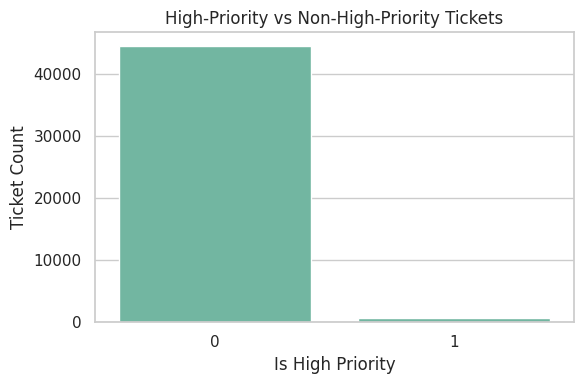

In [11]:
plt.figure(figsize=(6, 4))
sns.countplot(data=incidents, x="is_high_priority")
plt.title("High-Priority vs Non-High-Priority Tickets")
plt.xlabel("Is High Priority")
plt.ylabel("Ticket Count")
plt.tight_layout()
plt.show()

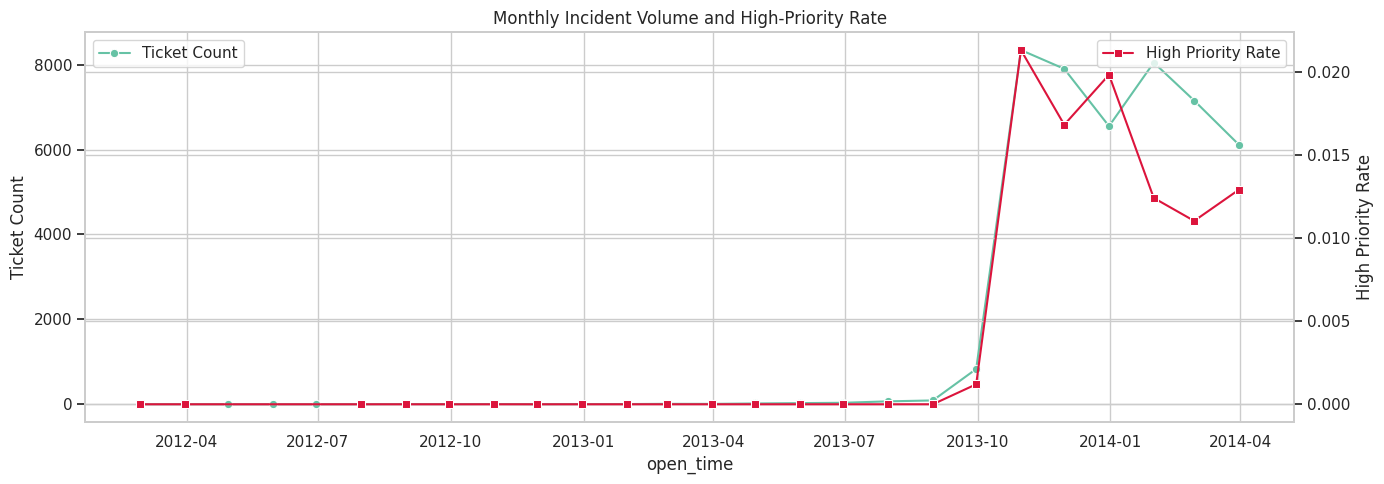

,quarter,ticket_count,high_priority_rate
0,2012Q1,2,0.000000
1,2012Q3,7,0.000000
2,2012Q4,10,0.000000
3,2013Q1,24,0.000000
4,2013Q2,81,0.000000
5,2013Q3,990,0.001010
6,2013Q4,22796,0.019345
7,2014Q1,21316,0.012104


In [12]:
if "open_time" in incidents.columns:
    trend_df = incidents.dropna(subset=["open_time"]).copy()
    monthly = (
        trend_df.set_index("open_time")
        .resample("M")
        .agg(ticket_count=("is_high_priority", "size"), high_priority_rate=("is_high_priority", "mean"))
        .reset_index()
    )

    fig, ax1 = plt.subplots(figsize=(14, 5))
    sns.lineplot(data=monthly, x="open_time", y="ticket_count", marker="o", ax=ax1, label="Ticket Count")
    ax1.set_ylabel("Ticket Count")
    ax2 = ax1.twinx()
    sns.lineplot(data=monthly, x="open_time", y="high_priority_rate", marker="s", color="crimson", ax=ax2, label="High Priority Rate")
    ax2.set_ylabel("High Priority Rate")
    plt.title("Monthly Incident Volume and High-Priority Rate")
    fig.tight_layout()
    plt.show()

    quarterly = (
        trend_df.assign(quarter=trend_df["open_time"].dt.to_period("Q").astype(str))
        .groupby("quarter")
        .agg(ticket_count=("is_high_priority", "size"), high_priority_rate=("is_high_priority", "mean"))
        .reset_index()
    )
    display(quarterly)
else:
    print("Open_Time column not available after cleaning.")

In [13]:
hotspot_cols = ["ci_cat", "ci_subcat", "ci_name", "wbs", "status", "alert_status", "closure_code"]

for col in [c for c in hotspot_cols if c in incidents.columns]:
    print(f"\nTop high-priority concentration by {col}")
    summary = (
        incidents.groupby(col)
        .agg(ticket_count=("is_high_priority", "size"), high_priority_rate=("is_high_priority", "mean"))
        .query("ticket_count >= 20")
        .sort_values(["high_priority_rate", "ticket_count"], ascending=False)
        .head(10)
    )
    display(summary)


Top high-priority concentration by ci_cat


,ticket_count,high_priority_rate
ci_cat,,
networkcomponents,99,0.222222
computer,3544,0.119921
,108,0.074074
hardware,406,0.014778
software,294,0.010204
storage,653,0.007657
application,31877,0.006117
subapplication,7720,0.004534
displaydevice,212,0.000000



Top high-priority concentration by ci_subcat


,ticket_count,high_priority_rate
ci_subcat,,
Banking Device,875,0.470857
Switch,26,0.384615
Network Component,27,0.111111
Windows Server,141,0.078014
,108,0.074074
DataCenterEquipment,243,0.020576
Automation Software,55,0.018182
MigratieDummy,58,0.017241
Citrix,762,0.014436



Top high-priority concentration by ci_name


...

,ticket_count,high_priority_rate
status,,
Closed,45218,0.015414



Top high-priority concentration by alert_status


,ticket_count,high_priority_rate
alert_status,,
closed,45226,0.015478



Top high-priority concentration by closure_code


,ticket_count,high_priority_rate
closure_code,,
,449,0.559020
Hardware,2831,0.039915
Referred,148,0.020270
Data,2144,0.012593
Operator error,1501,0.011326
Other,16110,0.009373
Software,12713,0.008889
Unknown,1538,0.005202
No error - works as designed,3449,0.002609


## 7. Priority Matrix Validation

In [14]:
if {"impact", "urgency", "priority"}.issubset(incidents.columns):
    observed_matrix = (
        incidents.groupby(["impact", "urgency"])["priority"]
        .agg(lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan)
        .unstack()
    )
    display(observed_matrix)
else:
    print("Impact, Urgency, and Priority are not all available.")

urgency,1.0,2.0,3.0,4.0,5.0
impact,,,,,
1.0,1.0,NaN,NaN,NaN,NaN
2.0,NaN,2.0,2.0,NaN,NaN
3.0,2.0,2.0,3.0,3.0,4.0
4.0,NaN,3.0,3.0,4.0,4.0
5.0,3.0,3.0,4.0,4.0,5.0


## 8. Modeling Plan

We train a binary classifier for:

```text
is_high_priority = 1 if Priority is 1 or 2
```

Interview note: since ITIL Priority is derived from Impact and Urgency, create two possible versions:

- **Operational model:** includes Impact and Urgency.
- **Strict early-risk model:** excludes Impact and Urgency to reduce target leakage.

Start with the operational model, then switch `INCLUDE_IMPACT_URGENCY = False` and compare results.

### Preprocessing Strategy

The preprocessing pipeline handles numerical and categorical features separately.

Numerical features are imputed using the median because ITSM data can contain outliers, such as unusually high reassignment counts or long handling times. Median imputation is more robust than mean imputation in the presence of outliers.

Categorical features are imputed using the most frequent value because fields such as CI category, CI subcategory, status, alert status, closure code, and WBS are discrete business labels.

One-hot encoding is used to convert categorical ITSM fields into machine-readable format. To avoid creating too many sparse columns from high-cardinality fields, category encoding is limited using `max_categories`.

Standard scaling is applied to numerical features for Logistic Regression. Tree-based models such as Random Forest and Gradient Boosting are less sensitive to scaling, but using a shared preprocessing pipeline keeps model comparison consistent.

## 9. Train/Test Split

In [15]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

def build_preprocessor(X):
    # Drop raw datetime columns before modeling
    X = X.copy()

    numeric_features = X.select_dtypes(include=["number", "bool"]).columns.tolist()
    categorical_features = X.select_dtypes(exclude=["number", "bool", "datetime64[ns]"]).columns.tolist()

    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore",
            max_categories=30
        )),
    ])

    return ColumnTransformer([
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features),
    ])

def get_candidate_models(random_state=42):
    return {
        "Logistic Regression": LogisticRegression(
            max_iter=300,
            class_weight="balanced",
            solver="liblinear",
            random_state=random_state,
        ),
        "Random Forest": RandomForestClassifier(
            n_estimators=100,
            max_depth=12,
            min_samples_leaf=5,
            class_weight="balanced_subsample",
            n_jobs=-1,
            random_state=random_state,
        ),
        "Gradient Boosting": GradientBoostingClassifier(
            n_estimators=80,
            max_depth=3,
            random_state=random_state,
        ),
    }

def build_model_pipeline(X, estimator):
    return Pipeline([
        ("preprocessor", build_preprocessor(X)),
        ("model", estimator),
    ])

In [16]:
INCLUDE_IMPACT_URGENCY = False

leakage_candidates = CLASSIFICATION_LEAKAGE_COLUMNS + [
    "incident_id", "related_interaction", "related_change", "kb_number"
]

if not INCLUDE_IMPACT_URGENCY:
    leakage_candidates += ["impact", "urgency"]

feature_cols = [col for col in incidents.columns if col not in leakage_candidates]

X = incidents[feature_cols].copy()
y = incidents["is_high_priority"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"Train rows: {X_train.shape[0]:,}")
print(f"Test rows: {X_test.shape[0]:,}")
print(f"Features used: {X_train.shape[1]:,}")
print(f"Included Impact/Urgency: {INCLUDE_IMPACT_URGENCY}")

Train rows: 36,180
Test rows: 9,046
Features used: 20
Included Impact/Urgency: False


## 10. Model Training and Comparison

In [17]:
results = []
trained_models = {}

for name, estimator in get_candidate_models(RANDOM_STATE).items():
    print(f"Training: {name}")
    model = build_model_pipeline(X_train, estimator)
    model.fit(X_train, y_train)
    metrics = score_classifier(model, X_test, y_test)
    trained_models[name] = model
    results.append({"model": name, **metrics})

results_df = pd.DataFrame(results).sort_values("avg_precision", ascending=False)
display(results_df)

Training: Logistic Regression
Training: Random Forest
Training: Gradient Boosting


,model,precision,recall,f1,roc_auc,avg_precision
2,Gradient Boosting,0.785714,0.078571,0.142857,0.957813,0.543212
1,Random Forest,0.348101,0.785714,0.482456,0.964588,0.520895
0,Logistic Regression,0.193333,0.828571,0.313514,0.958362,0.442417


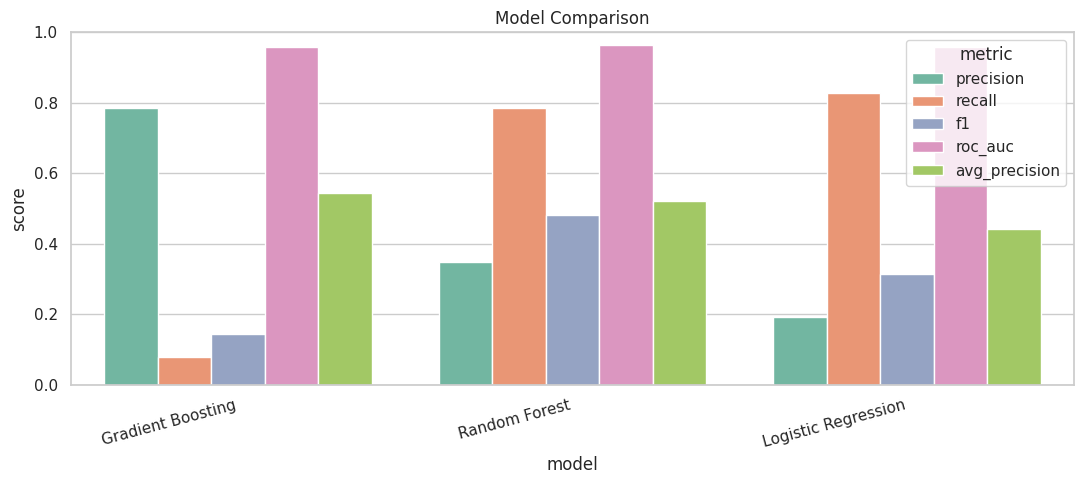

In [18]:
metric_cols = [col for col in ["precision", "recall", "f1", "roc_auc", "avg_precision"] if col in results_df.columns]

plt.figure(figsize=(11, 5))
plot_df = results_df.melt(id_vars="model", value_vars=metric_cols, var_name="metric", value_name="score")
sns.barplot(data=plot_df, x="model", y="score", hue="metric")
plt.ylim(0, 1)
plt.title("Model Comparison")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

### Target Leakage Check

When `Impact` and `Urgency` were included, tree-based models achieved near-perfect results. This happened because ITIL Priority is derived from Impact and Urgency using the priority matrix.

However, for a realistic early prediction system, the model should not rely on fields that directly determine the target. Therefore, a stricter model was trained by excluding `Impact`, `Urgency`, and `Priority`.

The stricter model provides a more honest estimate of how well machine learning can identify high-priority incidents before manual triage is fully completed.

## 11. Final Model Evaluation

In [19]:
best_model_name = results_df.iloc[0]["model"]
best_model = trained_models[best_model_name]

y_pred = best_model.predict(X_test)

print(f"Best model by average precision: {best_model_name}")
print("\nClassification Report")
print(classification_report(y_test, y_pred, zero_division=0))
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

Best model by average precision: Gradient Boosting

Classification Report
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      8906
           1       0.79      0.08      0.14       140

    accuracy                           0.99      9046
   macro avg       0.89      0.54      0.57      9046
weighted avg       0.98      0.99      0.98      9046


Confusion Matrix
[[8903    3]
 [ 129   11]]


In [20]:
best_model_name = "Random Forest"
best_model = trained_models[best_model_name]

y_pred = best_model.predict(X_test)

print(f"Business-selected final model: {best_model_name}")
print("\nClassification Report")
print(classification_report(y_test, y_pred, zero_division=0))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

Business-selected final model: Random Forest

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      8906
           1       0.35      0.79      0.48       140

    accuracy                           0.97      9046
   macro avg       0.67      0.88      0.73      9046
weighted avg       0.99      0.97      0.98      9046


Confusion Matrix
[[8700  206]
 [  30  110]]


### Final Model Selection

Although Gradient Boosting achieved the highest average precision, Random Forest was selected as the final business model because it provided a better recall-oriented tradeoff.

Random Forest correctly identified 110 out of 140 high-priority tickets in the test set, achieving 78.6% recall for Priority 1 and Priority 2 incidents. It missed only 30 high-priority tickets, while creating 206 false-positive review cases.

For ABC Tech, missing Priority 1/2 tickets is more costly than reviewing additional non-critical tickets. Therefore, Random Forest is the better operational choice for a high-risk incident triage queue.

### Hyperparameter Tuning - Random Forest

Random Forest was selected as the business-preferred model because it achieved strong recall for high-priority tickets. To improve the model further, a small hyperparameter tuning experiment was performed using RandomizedSearchCV.

The tuning focused on tree depth, number of estimators, minimum samples per leaf, and minimum samples per split. Because the dataset is imbalanced, recall and average precision are important evaluation metrics.

In [32]:
from sklearn.model_selection import RandomizedSearchCV

rf_pipeline = build_model_pipeline(
    X_train,
    RandomForestClassifier(
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=RANDOM_STATE
    )
)

param_distributions = {
    "model__n_estimators": [100, 150, 200],
    "model__max_depth": [8, 10, 12, 15],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [3, 5, 10],
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_distributions,
    n_iter=8,
    scoring="recall",
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=RANDOM_STATE
)

rf_search.fit(X_train, y_train)

print("Best parameters:")
print(rf_search.best_params_)

print(f"Best cross-validation recall: {rf_search.best_score_:.4f}")

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best parameters:
{'model__n_estimators': 200, 'model__min_samples_split': 5, 'model__min_samples_leaf': 10, 'model__max_depth': 12}
Best cross-validation recall: 0.7196


In [33]:
tuned_rf_model = rf_search.best_estimator_
y_pred_tuned = tuned_rf_model.predict(X_test)

print("Tuned Random Forest - Test Set Performance")
print(classification_report(y_test, y_pred_tuned, zero_division=0))
print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred_tuned))

Tuned Random Forest - Test Set Performance
              precision    recall  f1-score   support

           0       1.00      0.97      0.99      8906
           1       0.33      0.81      0.47       140

    accuracy                           0.97      9046
   macro avg       0.66      0.89      0.73      9046
weighted avg       0.99      0.97      0.98      9046

Confusion Matrix
[[8679  227]
 [  27  113]]


### Hyperparameter Tuning Insight

The tuned Random Forest improved high-priority recall from 78.6% to 80.7%, identifying 113 out of 140 Priority 1/2 tickets in the test set. The number of missed high-priority tickets reduced from 30 to 27.

This improvement came with a small tradeoff: false positives increased from 206 to 227. For ABC Tech, this is acceptable because the business cost of missing critical incidents is higher than the cost of reviewing additional non-critical tickets.

Therefore, the tuned Random Forest can be considered the final recommended model for a high-risk incident triage queue.

In [34]:
best_model_name = "Tuned Random Forest"
best_model = tuned_rf_model

In [35]:
rf_model = best_model
preprocessor = rf_model.named_steps["preprocessor"]
model = rf_model.named_steps["model"]

feature_names = preprocessor.get_feature_names_out()
importances = model.feature_importances_

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

feature_importance.head(20)

,feature,importance
55,cat__ci_subcat_Banking Device,0.154243
96,cat__wbs_WBS000146,0.127097
44,cat__ci_cat_computer,0.098489
39,cat__ci_name_infrequent_sklearn,0.064182
85,cat__wbs_WBS000073,0.057343
42,cat__ci_cat_application,0.052588
8,num__opened_hour,0.033159
1,num__no_of_related_interactions,0.032938
146,cat__category_incident,0.031395
112,cat__wbs_infrequent_sklearn,0.028296


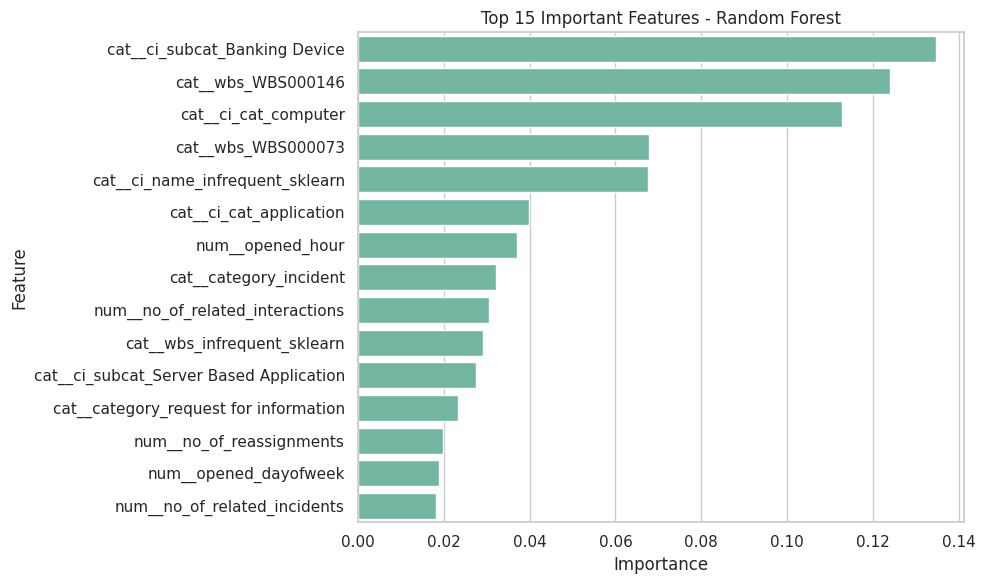

In [22]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance.head(15),
    x="importance",
    y="feature"
)
plt.title("Top 15 Important Features - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### Feature Importance Insight

The tuned Random Forest shows that high-priority prediction is mainly influenced by CI subcategory, WBS ownership group, CI category, incident category, opening time, related interactions, and reassignment behavior.

This improves model interpretability and makes the result easier to discuss with business stakeholders. The most important features should be reviewed with incident management teams to confirm whether they are available early enough in the ticket lifecycle and whether they reflect real operational risk.


In [38]:
best_model_name = "Tuned Random Forest"
best_model = tuned_rf_model

print(f"Business-selected final model: {best_model_name}")

Business-selected final model: Tuned Random Forest


In [39]:
from sklearn.metrics import precision_recall_curve

y_scores = best_model.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

threshold_df = pd.DataFrame({
    "threshold": list(thresholds) + [1.0],
    "precision": precision,
    "recall": recall
})

threshold_df[
    (threshold_df["recall"] >= 0.70) &
    (threshold_df["precision"] >= 0.20)
].head(10)

,threshold,precision,recall
6742,0.439736,0.200000,0.871429
6743,0.439895,0.200328,0.871429
6744,0.439948,0.200658,0.871429
6745,0.440075,0.200988,0.871429
6746,0.440212,0.201320,0.871429
6747,0.440217,0.201653,0.871429
6748,0.440464,0.201987,0.871429
6749,0.440707,0.202658,0.871429
6750,0.441002,0.202995,0.871429
6751,0.441179,0.202341,0.864286


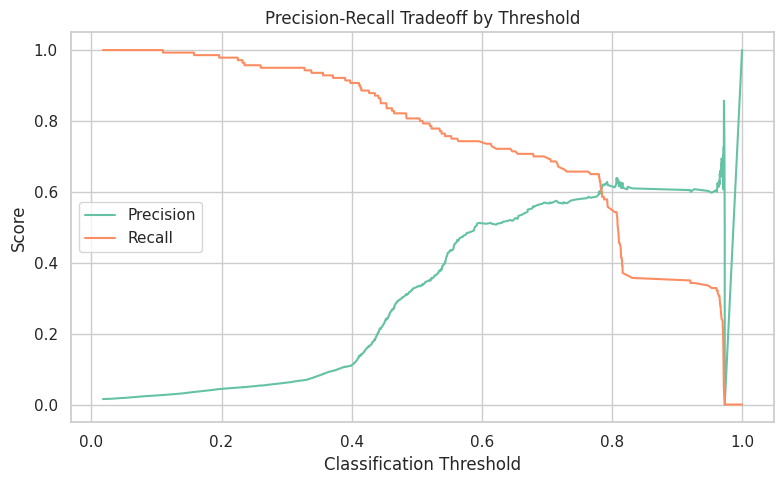

In [40]:
plt.figure(figsize=(8, 5))
plt.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall")
plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall Tradeoff by Threshold")
plt.legend()
plt.tight_layout()
plt.show()

### Threshold Tuning Insight

The default classification threshold is 0.50, but this may not be the best threshold for incident management. ABC Tech can adjust the threshold based on triage capacity and business risk.

If the support team wants to catch more Priority 1/2 tickets, the threshold can be lowered to improve recall. This may increase false positives, but it reduces the chance of missing critical incidents.

If the support team has limited review capacity, the threshold can be increased to improve precision and reduce false alarms.

This threshold tuning approach gives ABC Tech flexibility to choose an operating point based on SLA risk, staffing capacity, and the cost of missed high-priority tickets.

## 12. Business Interpretation

In [43]:
if hasattr(best_model, "predict_proba"):
    scored = X_test.copy()
    scored["actual_high_priority"] = y_test.values
    scored["predicted_high_priority_probability"] = best_model.predict_proba(X_test)[:, 1]
    scored = scored.sort_values("predicted_high_priority_probability", ascending=False)

    display(scored.head(15))

    top_10_pct = scored.head(max(1, int(len(scored) * 0.10)))
    print(f"High-priority rate in top 10% risk queue: {top_10_pct['actual_high_priority'].mean():.2%}")
    print(f"Overall high-priority rate: {y_test.mean():.2%}")

,ci_name,ci_cat,ci_subcat,wbs,status,number_cnt,category,alert_status,no_of_reassignments,open_time,reopen_time,no_of_related_interactions,no_of_related_incidents,no_of_related_changes,opened_year,opened_month,opened_quarter,opened_dayofweek,opened_hour,opened_is_weekend,actual_high_priority,predicted_high_priority_probability
12116,CBD000456,computer,Banking Device,WBS000146,Closed,0.200316025,incident,closed,0.0,2013-11-09 09:30:00,NaT,1.0,NaN,NaN,2013,11,4,5,9,1,0,0.973409
17963,CBD000905,computer,Banking Device,WBS000146,Closed,0.96389859,incident,closed,0.0,2013-12-02 09:07:00,NaT,1.0,NaN,NaN,2013,12,4,0,9,0,1,0.973378
19780,CBD000307,computer,Banking Device,WBS000146,Closed,0.594365383,incident,closed,0.0,2013-12-09 08:12:00,NaT,1.0,NaN,NaN,2013,12,4,0,8,0,1,0.972847
24124,CBD000493,computer,Banking Device,WBS000146,Closed,0.043329985,incident,closed,0.0,2013-12-30 08:46:00,NaT,1.0,NaN,NaN,2013,12,4,0,8,0,1,0.972847
23342,CBD000523,computer,Banking Device,WBS000146,Closed,0.54682816,incident,closed,0.0,2013-12-23 13:55:00,NaT,1.0,NaN,NaN,2013,12,4,0,13,0,1,0.972508
18397,CBD000610,computer,Banking Device,WBS000146,Closed,0.563749114,incident,closed,0.0,2013-12-03 08:40:00,NaT,1.0,NaN,NaN,2013,12,4,1,8,0,1,0.972338
23463,CBD000714,computer,Banking Device,WBS000146,Closed,0.874659693,incident,closed,0.0,2013-12-23 16:04:00,NaT,1.0,NaN,NaN,2013,12,4,0,16,0,1,0.972221
23022,CBD000919,computer,Banking Device,WBS000146,Closed,0.620852035,incident,closed,0.0,2013-12-20 11:09:00,NaT,1.0,NaN,NaN,2013,12,4,4,11,0,0,0.972156
21146,CBD001207,computer,Banking Device,WBS000146,Closed,0.902209786,incident,closed,0.0,2013-12-13 10:17:00,NaT,1.0,NaN,NaN,2013,12,4,4,10,0,1,0.972027
24443,CBD001167,computer,Banking Device,WBS000146,Closed,0.033477571,incident,closed,0.0,2013-12-31 11:18:00,NaT,1.0,NaN,NaN,2013,12,4,1,11,0,0,0.971996


High-priority rate in top 10% risk queue: 13.83%
Overall high-priority rate: 1.55%


## 13. Auto-Tagging Department Foundation

In [27]:
ownership_col = find_first_existing(incidents.columns, ["wbs", "assignment_group", "department"])

if ownership_col:
    owner_summary = (
        incidents[ownership_col]
        .value_counts(dropna=False)
        .rename_axis(ownership_col)
        .reset_index(name="ticket_count")
    )
    owner_summary["share"] = owner_summary["ticket_count"] / owner_summary["ticket_count"].sum()
    display(owner_summary.head(15))
    print(f"Candidate ownership label for future auto-tagging model: {ownership_col}")
    print(f"Unique labels: {incidents[ownership_col].nunique(dropna=True):,}")
else:
    print("No ownership/department proxy column found.")

,wbs,ticket_count,share
0,WBS000073,13292,0.293902
1,WBS000091,2439,0.053929
2,WBS000263,2277,0.050347
3,WBS000072,2190,0.048423
4,WBS000271,1182,0.026135
5,WBS000095,1099,0.024300
6,WBS000152,1074,0.023747
7,WBS000318,1062,0.023482
8,WBS000094,859,0.018993
9,WBS000146,825,0.018242


Candidate ownership label for future auto-tagging model: wbs
Unique labels: 273


## 14. Final Recommendations

- Use predicted probability to create a high-risk incident triage queue.
- Prioritize recall when missed Priority 1/2 tickets are more costly than extra review workload.
- Monitor CI categories, CI subcategories, WBS groups, and reassignment-heavy tickets.
- Use quarterly incident volume trends for staffing and technology planning.
- Build a second model for WBS/department auto-tagging after validating the ownership label.
- Extend the project later with RFC/change-risk analysis using related change fields.

## Limitations and Future Work

- The dataset is historical and covers 2012-2014, so model performance should be monitored before real deployment.
- The data is highly imbalanced, with only about 1.5% high-priority tickets.
- `Impact` and `Urgency` were excluded from the stricter model to reduce target leakage because Priority is derived from the ITIL priority matrix.
- Some fields may not be available at the exact time a ticket is created, so production deployment should confirm feature availability timing.
- Future work can include hyperparameter tuning using GridSearchCV or RandomizedSearchCV.
- Cost-sensitive learning, SMOTE, or advanced imbalance-handling techniques can be explored to improve high-priority detection.
- A second model can be developed for WBS/department auto-tagging, but the 273 unique WBS labels require careful class imbalance handling.
- RFC/change-risk prediction can be explored using related change and related incident fields.
- Model performance should be monitored over time using recall, precision, average precision, and false-negative counts.

## 15. Save Model

In [42]:
model_file = "abc_tech_high_priority_ticket_model.joblib"
joblib.dump(best_model, model_file)
print(f"Saved model: {model_file}")

files.download(model_file)

Saved model: abc_tech_high_priority_ticket_model.joblib


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 16. Resume Summary

**ABC Tech ITSM Incident Prioritization | Machine Learning Capstone**

Built an end-to-end ML solution on approximately 46k ITSM incident records from 2012-2014 to predict Priority 1 and Priority 2 tickets and analyze operational trends. Engineered ITIL lifecycle, CI, reassignment, relationship-count, and time-based features; compared Logistic Regression, Random Forest, Gradient Boosting, and tuned Random Forest models; evaluated performance using recall, F1, ROC-AUC, average precision, and threshold tuning; and translated model outputs into SLA-focused triage and resource-planning recommendations.

## Executive Summary

ABC Tech receives a high volume of ITSM incidents and wants to improve incident management using machine learning. This project focused on predicting Priority 1 and Priority 2 incidents, analyzing operational trends, and creating a foundation for ticket auto-tagging.

The dataset contained 46,606 records from 2012-2014. After cleaning and target preparation, 45,226 records were used for modeling. Only 700 tickets were high priority, making this a highly imbalanced classification problem.

A leakage-aware modeling approach was used. The first experiment showed near-perfect results when `Impact` and `Urgency` were included, but these fields directly influence `Priority`. Therefore, a stricter model excluded `Impact`, `Urgency`, and `Priority`.

After hyperparameter tuning, the tuned Random Forest was selected as the final business model because it captured 113 out of 140 high-priority tickets in the test set, achieving 80.7% recall. The model also increased the high-priority rate in the top 10% risk queue from 1.55% overall to 13.83%, giving nearly 9x better prioritization than random ticket review.

The recommended business use is to deploy the model as a high-risk triage queue, where support teams review tickets with the highest predicted probability of becoming Priority 1 or Priority 2.